##Install's

In [3]:
!pip install dbfread


In [4]:
!pip install dbc_reader

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for dbc_reader: filename=dbc_reader-0.1.2-py3-none-any.whl size=18495 sha256=de336510f27e4811e84748623d1a25fcedc0843430c03bbb8cb7c947024e55f1
  Stored in directory: /root/.cache/pip/wheels/d3/87/0e/aa89785005d4e0f7002d6bb41a11af99c8d58a18bfefc65f90
  Created wheel for dbf-reader: filename=dbf_reader-0.2.2-py3-none-any.whl size=7623 sha256=cb6f4a74de92565f058649f3081ba573bdfa636bc7eea87469e3b4ba478fb70b
  Stored in directory: /root/.cache/pip/wheels/32/c5/00/0dd049f439df1744823cd5fd0321683870f4e5bfc16c4c7419
Successfully built dbc_reader dbf-reader


In [5]:
!pip install dbfread

In [6]:
!pip install PySUS


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
!pip install pysus # install the correct package name, pysus

In [8]:
pip install datasus-dbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.6 MB/s eta 0:00:00


In [9]:
import pandas as pd
from dbfread import DBF  # Biblioteca para ler arquivos DBF

# Função para ler um arquivo DBF específico e converter para CSV
def ler_e_converter_dbf_para_csv(caminho_dbf, caminho_csv):
    try:
        # Ler arquivo DBF usando dbfread
        tabela_dbf = DBF(caminho_dbf, encoding="latin-1")
        df = pd.DataFrame(iter(tabela_dbf))

        # Salvar como CSV
        df.to_csv(
            caminho_csv,
            index=False,
            sep=';',  # Ponto e vírgula como separador
            encoding='utf-8',  # Codificação segura para CSV
            escapechar='\\',  # Escapar caracteres especiais
            quoting=1  # Quoting para campos com caracteres especiais
        )
        print(f"Arquivo '{caminho_dbf}' convertido e salvo como '{caminho_csv}'.")

        return df
    except Exception as e:
        print(f"Erro ao processar o arquivo: {e}")
        return None

# Caminho do arquivo DBF e destino CSV
caminho_dbf = "/content/dados_sim/DOAM2018.dbf"  # Substitua pelo nome desejado
caminho_csv = "DOAM2018.csv"  # Nome do arquivo CSV gerado

# Executar a conversão e leitura
df_convertido = ler_e_converter_dbf_para_csv(caminho_dbf, caminho_csv)

# Exibir as primeiras linhas do DataFrame
if df_convertido is not None:
    print("Primeiras linhas do DataFrame:")
    print(df_convertido.head())


Erro ao processar o arquivo: could not find file '/content/dados_sim/DOAM2018.dbf'


##Função Principal

####Imports

In [10]:
import ftplib
import os
import pandas as pd
from dbfread import DBF  # Para ler arquivos DBF
import datasus_dbc  # Biblioteca para descompressão de DBC
import seaborn as sns
import matplotlib.pyplot as plt # Import the pyplot module as plt

###Configurações e estruturas

In [11]:
# Lista de estados da Amazônia Legal
estados_amazonia_legal = ["AC", "AM", "AP", "MA", "MT", "PA", "RO", "RR", "TO"]

amazonia = ["AM"]

# Lista das colunas específicas a serem mantidas

colunas_selecionadas = [
         "DTOBITO", "HORAOBITO", "DTNASC", "IDADE", "SEXO", "RACACOR", "ESTCIV", "ESC",
        "LOCOCOR", "GRAVIDEZ", "CAUSABAS_O", "ANO", "ESTADO"
    ]

colunas_selecionadas_antigo = [
        "TIPOBITO", "DTOBITO", "HORAOBITO", "NATURAL", "CODMUNNATU",
        "DTNASC", "IDADE", "SEXO", "RACACOR", "ESTCIV", "ESC",
        "CODMUNRES", "LOCOCOR", "CODMUNOCOR", "GRAVIDEZ", "LINHAA",
        "LINHAB", "LINHAC", "LINHAD", "LINHAII", "CAUSABAS", "CAUSABAS_O", "ANO", "ESTADO"
    ]

In [12]:
# "Y01", "Y02", "Y03", "Y04", "Y05", "Y06", "Y07", "Y08", "Y09", "Y00"

cid10_codigos = [
    "X85", "X86", "X87", "X88", "X89", "X90", "X91", "X92", "X93", "X94", "X95", "X96", "X97", "X98", "X99",
    "Y10" , "Y11", "Y12", "Y13", "Y14", "Y15", "Y16", "Y17", "Y18", "Y19", "Y20", "Y21", "Y22", "Y23", "Y24",
    "Y25", "Y26", "Y27", "Y28", "Y29", "Y30", "Y31", "Y32", "Y33", "Y34"
]

In [13]:
# Configurações
diretorio_remoto = "/dissemin/publicos/SIM/CID10/DORES/"
diretorio_local = "./dados_sim/"
anos_especificos = ["2012","2013","2014","2015","2016","2017","2018", "2019","2020","2021","2022","2023"]  # Adicione os anos desejados

###Extração dos dados da fonte, conversão de .dbc para .dbf, junção entre as tabelas de Óbito com relação ao ano e estados, e geração de um arquivo .csv

In [14]:


# Etapa 1: Baixar arquivos DBC do FTP do DATASUS e converter para DBF
def baixar_e_converter_arquivos(diretorio_remoto, diretorio_local, anos):
    try:
        # Conectar ao servidor FTP do DATASUS
        ftp = ftplib.FTP("ftp.datasus.gov.br")
        ftp.login()
        ftp.cwd(diretorio_remoto)

        # Listar os arquivos do diretório remoto
        arquivos = ftp.nlst()

        if not os.path.exists(diretorio_local):
            os.makedirs(diretorio_local)

        # Filtrar e baixar arquivos de cada ano
        for ano in anos:
            arquivos_filtrados = [
                arq for arq in arquivos
                if arq.endswith(f"{ano}.dbc") and arq[2:4] in estados_amazonia_legal[4]   #trocar entre amazonia ou estados_amazonia_legal
            ]

            for arquivo in arquivos_filtrados:
                caminho_dbc = os.path.join(diretorio_local, arquivo)
                caminho_dbf = caminho_dbc.replace(".dbc", ".dbf")

                # Baixar arquivo
                with open(caminho_dbc, "wb") as f:
                    ftp.retrbinary(f"RETR {arquivo}", f.write)
                    print(f"Baixado: {arquivo}")

                # Converter arquivo DBC para DBF
                datasus_dbc.decompress(caminho_dbc, caminho_dbf)
                print(f"Convertido: {arquivo} para DBF")

        ftp.quit()
        print("Download e conversão concluídos.")
    except Exception as e:
        print(f"Erro ao baixar ou converter arquivos: {e}")

# Etapa 2: Unir as tabelas DBF em um único DataFrame com colunas Estado e Ano
def unir_arquivos_dbf(diretorio_local):
    dataframes = []
    for arquivo in os.listdir(diretorio_local):
        if arquivo.endswith(".dbf"):
            caminho_arquivo = os.path.join(diretorio_local, arquivo)

            # Ler arquivo DBF
            table = DBF(caminho_arquivo, encoding="latin-1")
            df = pd.DataFrame(iter(table))

            # Adicionar colunas de Estado e Ano
            estado = arquivo[2:4]  # Exemplo: "DOAC2019.dbf" -> "AC"
            ano = arquivo[4:8]     # Exemplo: "DOAC2019.dbf" -> "2019"
            df["ESTADO"] = estado
            df["ANO"] = ano
            dataframes.append(df)
            print(f"Processado: {arquivo}")

    # Concatenar todos os DataFrames em um único
    df_final = pd.concat(dataframes, ignore_index=True)
    return df_final

# Executar etapas
baixar_e_converter_arquivos(diretorio_remoto, diretorio_local, anos_especificos)
df_unificado = unir_arquivos_dbf(diretorio_local)

# Exibir as primeiras linhas do DataFrame final
print(df_unificado.head())

# Salvar em CSV com segurança de escape
df_unificado.to_csv(
    "mortalidade_unificada.csv",
    index=False,
    sep=';',  # Usar ponto e vírgula como separador
    encoding='utf-8',  # Codificação segura
    escapechar='\\',  # Escape de caracteres especiais
    quoting=1  # Quoting para campos especiais
)
print("Arquivo unificado salvo como 'mortalidade_unificada.csv'.")


Baixado: DOMT2013.dbc
Convertido: DOMT2013.dbc para DBF
Baixado: DOMT2014.dbc
Convertido: DOMT2014.dbc para DBF
Baixado: DOMT2015.dbc
Convertido: DOMT2015.dbc para DBF
Baixado: DOMT2016.dbc
Convertido: DOMT2016.dbc para DBF
Baixado: DOMT2017.dbc
Convertido: DOMT2017.dbc para DBF
Baixado: DOMT2018.dbc
Convertido: DOMT2018.dbc para DBF
Baixado: DOMT2019.dbc
Convertido: DOMT2019.dbc para DBF
Baixado: DOMT2020.dbc
Convertido: DOMT2020.dbc para DBF
Baixado: DOMT2021.dbc
Convertido: DOMT2021.dbc para DBF
Baixado: DOMT2022.dbc
Convertido: DOMT2022.dbc para DBF
Baixado: DOMT2023.dbc
Convertido: DOMT2023.dbc para DBF
Download e conversão concluídos.
Processado: DOMT2018.dbf
Processado: DOMT2020.dbf
Processado: DOMT2015.dbf
Processado: DOMT2023.dbf
Processado: DOMT2013.dbf
Processado: DOMT2014.dbf
Processado: DOMT2019.dbf
Processado: DOMT2021.dbf
Processado: DOMT2017.dbf
Processado: DOMT2016.dbf
Processado: DOMT2022.dbf
  ORIGEM TIPOBITO   DTOBITO HORAOBITO NATURAL CODMUNNATU    DTNASC IDADE SEX

In [15]:

# Filtrar o DataFrame para conter apenas as colunas que existem em df_unificado
colunas_existentes = [col for col in colunas_selecionadas if col in df_unificado.columns]

# Criar o novo DataFrame com as colunas desejadas
df_novo = df_unificado[colunas_existentes].copy()

# Exibir as primeiras linhas do novo DataFrame
print(df_novo.head())

# Verificar informações do novo DataFrame
print(df_novo.info())

    DTOBITO HORAOBITO    DTNASC IDADE SEXO RACACOR ESTCIV ESC LOCOCOR  \
0  07072018      0910  21061955   463    2       1      3   3       1   
1  18042018      1220  20011919   499    2       1      3   2       3   
2  08012018      0830  18021937   480    2       4      2   1       3   
3  30082018      1236  21101969   448    1       4      2   9       4   
4  04032018      0800  07081931   486    2       5                  6   

  GRAVIDEZ CAUSABAS_O   ANO ESTADO  
0                L028  2018     MT  
1                N390  2018     MT  
2                 I64  2018     MT  
3                V494  2018     MT  
4                      2018     MT  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217532 entries, 0 to 217531
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   DTOBITO     217532 non-null  object
 1   HORAOBITO   217532 non-null  object
 2   DTNASC      217532 non-null  object
 3   IDADE       217532

Filtrar a coluna CAUSABAS_O para os dados que interessam

In [16]:
# Filtrando o DataFrame com códigos que começam com os valores da lista
df_filtrado = df_novo.copy()

# Removendo a coluna ESTADO
# df_filtrado = df_filtrado.drop(columns=["ESTADO"])

# Exibindo as primeiras linhas do DataFrame filtrado
print(df_filtrado.head())

    DTOBITO HORAOBITO    DTNASC IDADE SEXO RACACOR ESTCIV ESC LOCOCOR  \
0  07072018      0910  21061955   463    2       1      3   3       1   
1  18042018      1220  20011919   499    2       1      3   2       3   
2  08012018      0830  18021937   480    2       4      2   1       3   
3  30082018      1236  21101969   448    1       4      2   9       4   
4  04032018      0800  07081931   486    2       5                  6   

  GRAVIDEZ CAUSABAS_O   ANO ESTADO  
0                L028  2018     MT  
1                N390  2018     MT  
2                 I64  2018     MT  
3                V494  2018     MT  
4                      2018     MT  


In [17]:
df_filtrado

,DTOBITO,HORAOBITO,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,LOCOCOR,GRAVIDEZ,CAUSABAS_O,ANO,ESTADO
0,07072018,0910,21061955,463,2,1,3,3,1,,L028,2018,MT
1,18042018,1220,20011919,499,2,1,3,2,3,,N390,2018,MT
2,08012018,0830,18021937,480,2,4,2,1,3,,I64,2018,MT
3,30082018,1236,21101969,448,1,4,2,9,4,,V494,2018,MT
4,04032018,0800,07081931,486,2,5,,,6,,,2018,MT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217527,01062022,0040,23032021,401,1,5,,,6,,,2022,MT
217528,21052022,1145,22052009,412,1,5,,2,6,,,2022,MT
217529,10112022,0430,15071939,483,2,5,,9,6,,,2022,MT
217530,16112022,1620,07091936,486,1,5,,9,6,,,2022,MT


In [18]:
df_filtrado.to_csv(
    "filtrado.csv",
    index=False,
    sep=';',  # Usar ponto e vírgula como separador
    encoding='utf-8',  # Codificação segura
    escapechar='\\',  # Escape de caracteres especiais
    quoting=1  # Quoting para campos especiais
)

In [19]:
# df_novo['TIPOBITO'] = df_novo['TIPOBITO'].replace('1', 'fetal')
# df_novo['TIPOBITO'] = df_novo['TIPOBITO'].replace('2', 'não fetal')



df_novo['RACACOR'] = df_novo['RACACOR'].replace('1', 'branca')
df_novo['RACACOR'] = df_novo['RACACOR'].replace('2', 'preta')
df_novo['RACACOR'] = df_novo['RACACOR'].replace('3', 'amarela')
df_novo['RACACOR'] = df_novo['RACACOR'].replace('4', 'parda')
df_novo['RACACOR'] = df_novo['RACACOR'].replace('5', 'indigena')




df_novo['ESTCIV'] = df_novo['ESTCIV'].replace('1', 'solteiro')
df_novo['ESTCIV'] = df_novo['ESTCIV'].replace('2', 'casado')
df_novo['ESTCIV'] = df_novo['ESTCIV'].replace('3', 'viuvo')
df_novo['ESTCIV'] = df_novo['ESTCIV'].replace('4', 'separado')
df_novo['ESTCIV'] = df_novo['ESTCIV'].replace('5', 'união estável')
df_novo['ESTCIV'] = df_novo['ESTCIV'].replace('9', 'ignorado')



#df_novo['SEXO'] = df_novo['SEXO'].replace('M', 'masculino')
#df_novo['SEXO'] = df_novo['SEXO'].replace('F', 'feminino')
#df_novo['SEXO'] = df_novo['SEXO'].replace('I', 'ignorado')



df_novo['ESC'] = df_novo['ESC'].replace('1', 'nenhuma')
df_novo['ESC'] = df_novo['ESC'].replace('2', '1 a 3 anos')
df_novo['ESC']  = df_novo['ESC'].replace('3', '4 a 7 anos')
df_novo['ESC']  = df_novo['ESC'].replace('4', '8 a 11 anos')
df_novo['ESC']  = df_novo['ESC'].replace('5', '12 anos e mais')
df_novo['ESC']  = df_novo['ESC'].replace('9', 'ignorado')


df_novo['GRAVIDEZ'] = df_novo['GRAVIDEZ'].replace('1', 'única')
df_novo['GRAVIDEZ'] = df_novo['GRAVIDEZ'].replace('2', 'dupla')
df_novo['GRAVIDEZ'] = df_novo['GRAVIDEZ'].replace('3', 'tripla e mais')
df_novo['GRAVIDEZ'] = df_novo['GRAVIDEZ'].replace('9', 'ignorada')

df_novo['LOCOCOR'] = df_novo['LOCOCOR'].replace('1', 'hospital')
df_novo['LOCOCOR'] = df_novo['LOCOCOR'].replace('3', 'domicílio')
df_novo['LOCOCOR'] = df_novo['LOCOCOR'].replace('4', 'via pública')
df_novo['LOCOCOR'] = df_novo['LOCOCOR'].replace('2', 'outros estabelecimentos de saude')
df_novo['LOCOCOR'] = df_novo['LOCOCOR'].replace('5', 'outros')
df_novo['LOCOCOR'] = df_novo['LOCOCOR'].replace('9', 'ignorado')

In [20]:
df_filtrado['SEXO'].value_counts()

,count
SEXO,
1,135100
2,82320
0,112


Verifiquei no http://tabnet.datasus.gov.br/cgi/tabcgi.exe?sim/cnv/obt10am.def  para descobrir o que significa a codificação 1, 2 e 0

In [21]:
#df_novo['SEXO'] = df_novo['SEXO'].replace('1', 'masculino')
#df_novo['SEXO'] = df_novo['SEXO'].replace('2', 'feminino')
#df_novo['SEXO'] = df_novo['SEXO'].replace('0', 'ignorado')

###Visualização dos dados

In [22]:
df_filtrado.describe()

,DTOBITO,HORAOBITO,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,LOCOCOR,GRAVIDEZ,CAUSABAS_O,ANO,ESTADO
count,217532,217532,217532,217532,217532,217532,217532,217532,217532,217532,217532,217532,217532
unique,4017,1442,36437,239,3,6,7,8,7,5,4002,11,1
top,02042021,,,474,1,4,2,3,1,,B342,2021,MT
freq,169,4632,785,4294,135100,115085,67711,51664,143213,209629,14656,28623,217532


In [23]:
# Exibir os tipos de dados de cada coluna
print("Tipos de dados das colunas:")
print(df_filtrado.dtypes)
print("\n" + "-"*50)

# Obter estatísticas descritivas
print("Estatísticas descritivas:")
print(df_filtrado.describe())
print("\n" + "-"*50)


# Exibir os valores únicos de cada coluna em listas
print("Valores únicos de cada coluna:")
for coluna in df_filtrado.columns:
    valores_unicos = df_filtrado[coluna].unique()
    print(f"\nColuna: {coluna}")
    print(f"Total de valores únicos: {len(valores_unicos)}")
    print(f"Valores únicos: {valores_unicos[:10]}")  # Exibe os 10 primeiros valores únicos
    if len(valores_unicos) > 10:
        print(f"... e mais {len(valores_unicos) - 10} valores.")
print("\n" + "-"*50)

# Exibir informações gerais do DataFrame
print("Informações gerais do DataFrame:")
print(df_filtrado.info())


Tipos de dados das colunas:
DTOBITO       object
HORAOBITO     object
DTNASC        object
IDADE         object
SEXO          object
RACACOR       object
ESTCIV        object
ESC           object
LOCOCOR       object
GRAVIDEZ      object
CAUSABAS_O    object
ANO           object
ESTADO        object
dtype: object

--------------------------------------------------
Estatísticas descritivas:
         DTOBITO HORAOBITO  DTNASC   IDADE    SEXO RACACOR  ESTCIV     ESC  \
count     217532    217532  217532  217532  217532  217532  217532  217532   
unique      4017      1442   36437     239       3       6       7       8   
top     02042021                       474       1       4       2       3   
freq         169      4632     785    4294  135100  115085   67711   51664   

       LOCOCOR GRAVIDEZ CAUSABAS_O     ANO  ESTADO  
count   217532   217532     217532  217532  217532  
unique       7        5       4002      11       1  
top          1                B342    2021      MT  
freq

In [24]:
import pandas as pd
from dbfread import DBF

def carregar_sim_mato_grosso(caminho_dbf):
    tabela = DBF(caminho_dbf, encoding="latin-1")
    df = pd.DataFrame(iter(tabela))

    # Filtrar por Mato Grosso (código de estado = 51)
    # CODMUNOCOR: município de ocorrência do óbito
    # Os primeiros 2 dígitos = código do estado
    df['COD_ESTADO'] = df['CODMUNOCOR'].astype(str).str[:2]
    df_mt = df[df['COD_ESTADO'] == '51'].copy()

    print(f"Total de registros: {len(df)}")
    print(f"Registros do Mato Grosso: {len(df_mt)}")
    return df_mt

# Carregar múltiplos anos
anos = range(2020, 2023)
dfs = []
for ano in anos:
    caminho = f"/content/dados_sim/DOMT{ano}.dbf"
    try:
        df_ano = carregar_sim_mato_grosso(caminho)
        df_ano['ANO'] = ano
        dfs.append(df_ano)
        print(f"Ano {ano}: {len(df_ano)} registros")
    except FileNotFoundError:
        print(f"Arquivo {ano} não encontrado")

df_mt_total = pd.concat(dfs, ignore_index=True)
df_mt_total.to_csv("SIM_MatoGrosso_2015_2022.csv", sep=';', index=False, encoding='utf-8')

Total de registros: 23397
Registros do Mato Grosso: 22980
Ano 2020: 22980 registros
Total de registros: 28623
Registros do Mato Grosso: 27999
Ano 2021: 27999 registros
Total de registros: 21731
Registros do Mato Grosso: 21221
Ano 2022: 21221 registros


In [25]:
df_mt_total

,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,...,TPNIVELINV,NUDIASINF,DTCADINF,MORTEPARTO,DTCONCASO,FONTESINF,ALTCAUSA,CONTADOR,COD_ESTADO,ANO
0,1,2,29062020,1414,851,510010,20051939,481,2,1,...,,,,,,,,14,51,2020
1,1,2,29062020,0600,851,510610,16121953,466,1,4,...,,,,,,,,15,51,2020
2,1,2,28062020,2300,851,510340,19041983,437,1,4,...,,,,,,,,16,51,2020
3,1,2,27062020,0735,851,510340,26062020,201,1,4,...,,,04062021,3,20052021,,2,17,51,2020
4,1,2,27062020,1215,835,353250,21091960,459,1,1,...,,,,,,,,18,51,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72195,1,2,01062022,0040,851,510020,23032021,401,1,5,...,,,12092022,3,12092022,,2,1544178,51,2022
72196,1,2,21052022,1145,851,510706,22052009,412,1,5,...,,,,,,,,1544179,51,2022
72197,1,2,10112022,0430,851,510706,15071939,483,2,5,...,,,,,,,,1544205,51,2022
72198,1,2,16112022,1620,851,510270,07091936,486,1,5,...,,,,,,,,1544206,51,2022



NaNs após correção dos mapas:
IDADE_NUM      1771
HORA_NUM       4637
SEXO_NUM          0
RACACOR_NUM       0
ESTCIV_NUM        0
ESC_NUM           0
LOCOCOR_NUM      53
ANO_NUM           0
dtype: int64
Total de registros: 217532

Amostra bruta de IDADE (antes da decodificação):
['463', '499', '480', '448', '486', '416', '473', '456', '465', '455', '478', '475', '485', '488', '448', '481', '485', '464', '469', '477']
Tipo da coluna: object
NaN em IDADE: 0 / 217532

NaNs restantes após imputação: 0
Features utilizadas: ['IDADE_NUM', 'HORA_NUM', 'ANO_NUM', 'SEXO_NUM', 'RACACOR_NUM', 'ESTCIV_NUM', 'ESC_NUM', 'LOCOCOR_NUM']
Shape final: (217532, 9)

Registros para clusterização: 217532
Homicídios oficiais (CID-10): 12302 (5.7%)

═════════════════════════════════════════════════════════════════
  K-MEANS — TREINAMENTO E MÉTRICAS
═════════════════════════════════════════════════════════════════

  K = 2
    WCSS (Inércia):        1,509,484.9  ← menor melhor
    Silhouette:            0.1400

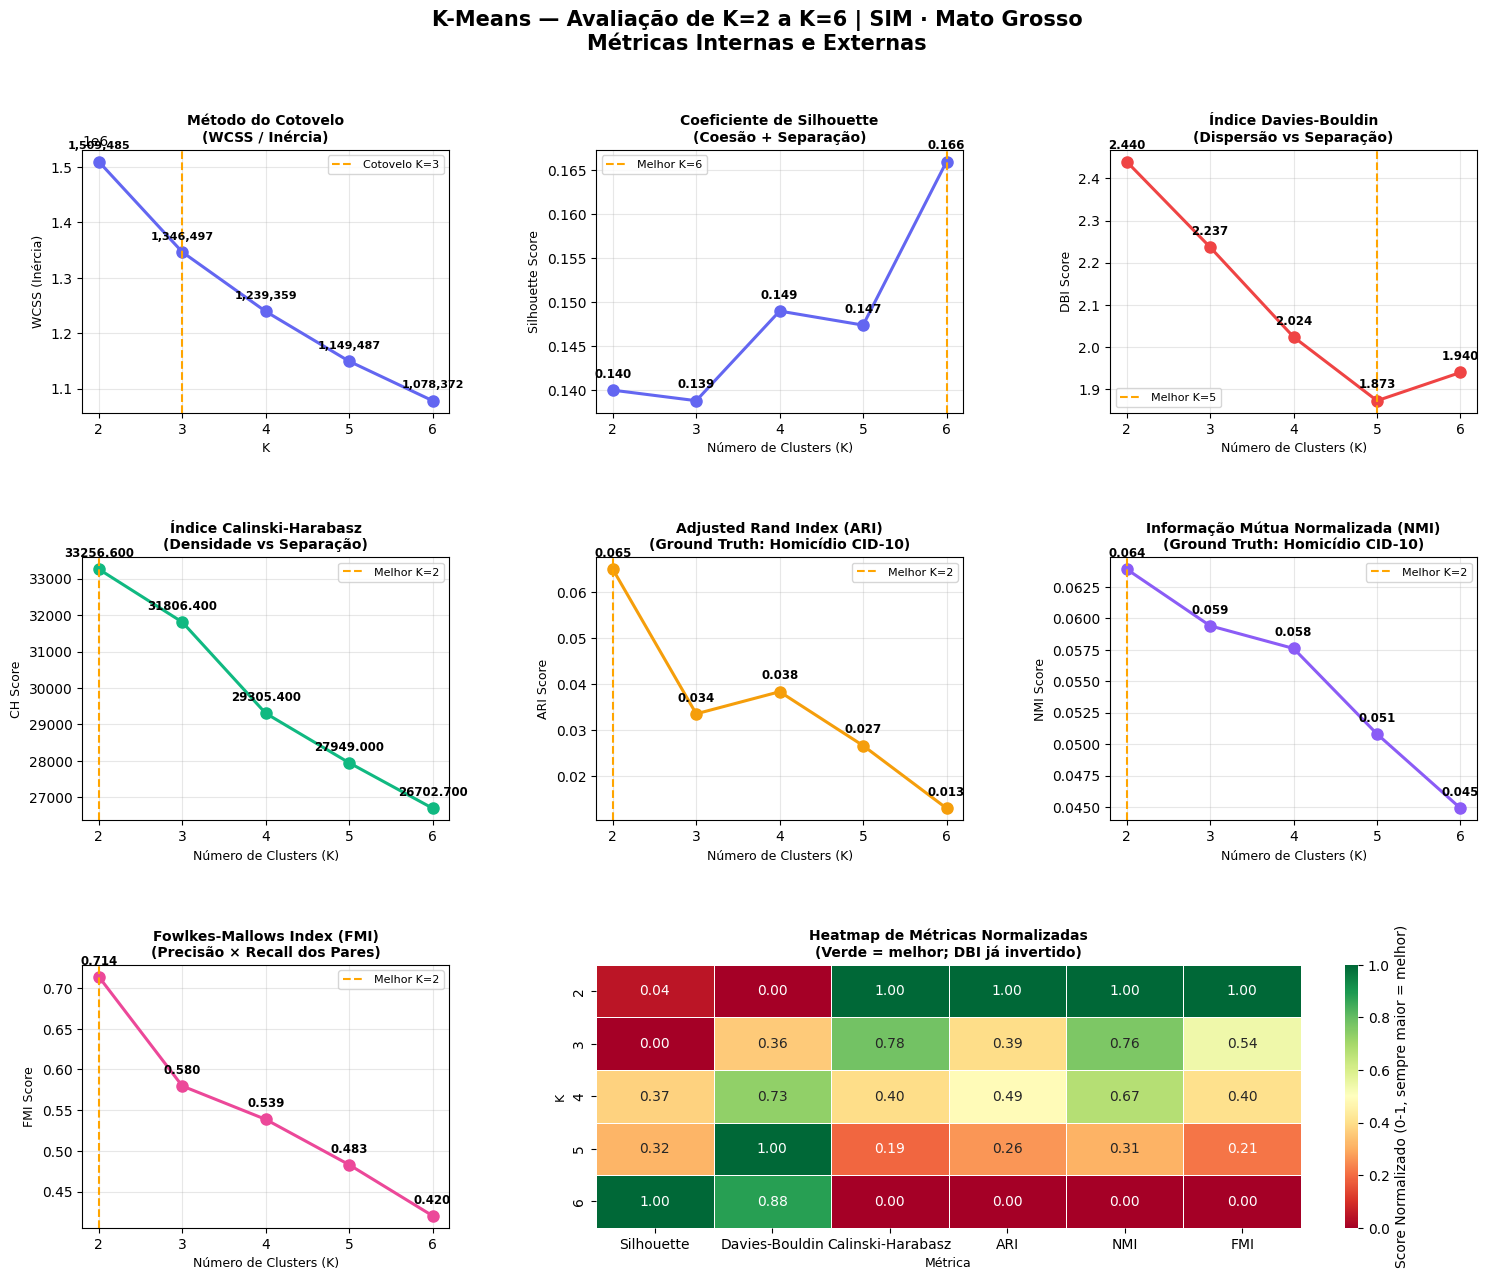

Gráfico salvo: kmeans_metricas_completas.png


/tmp/ipykernel_8315/50354575.py:396: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


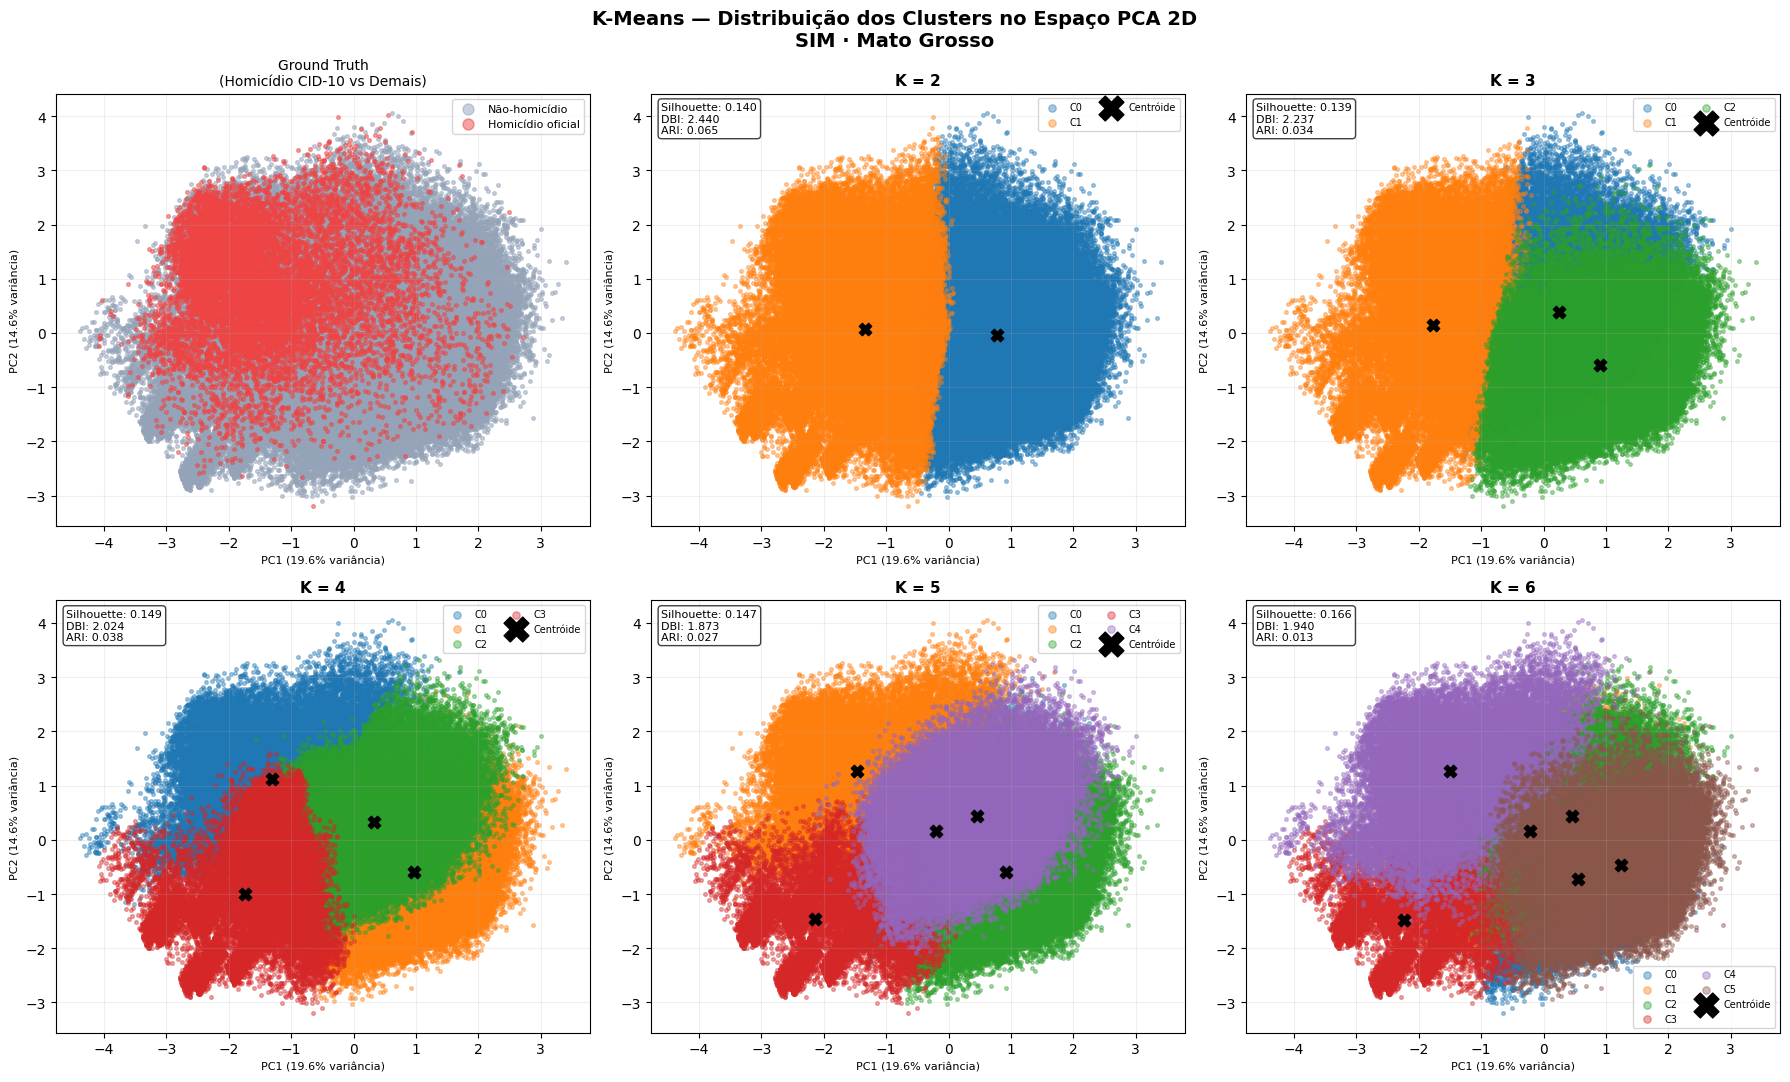

Gráfico salvo: kmeans_pca_clusters.png

═════════════════════════════════════════════════════════════════
  MELHOR K — Silhouette:            K = 6
  MELHOR K — ARI (concordância):     K = 2
  MELHOR K — Pureza do cluster alvo: K = 6
  → K escolhido: 6 (maior enriquecimento de homicídios)
═════════════════════════════════════════════════════════════════

Proporção de homicídios por cluster (K=6):
                   N_Homicidios  Prop_Homicidio  N_Total
CLUSTER_KMEANS_K6                                       
4                          7656        0.268688    28494
3                           649        0.044270    14660
1                          1956        0.036679    53328
2                          1236        0.026038    47469
0                           439        0.011595    37860
5                           366        0.010246    35721

─────────────────────────────────────────────────────────────────
  CANDIDATOS A HOMICÍDIO OCULTO (K-Means, K=6):
  Cluster alvo:              

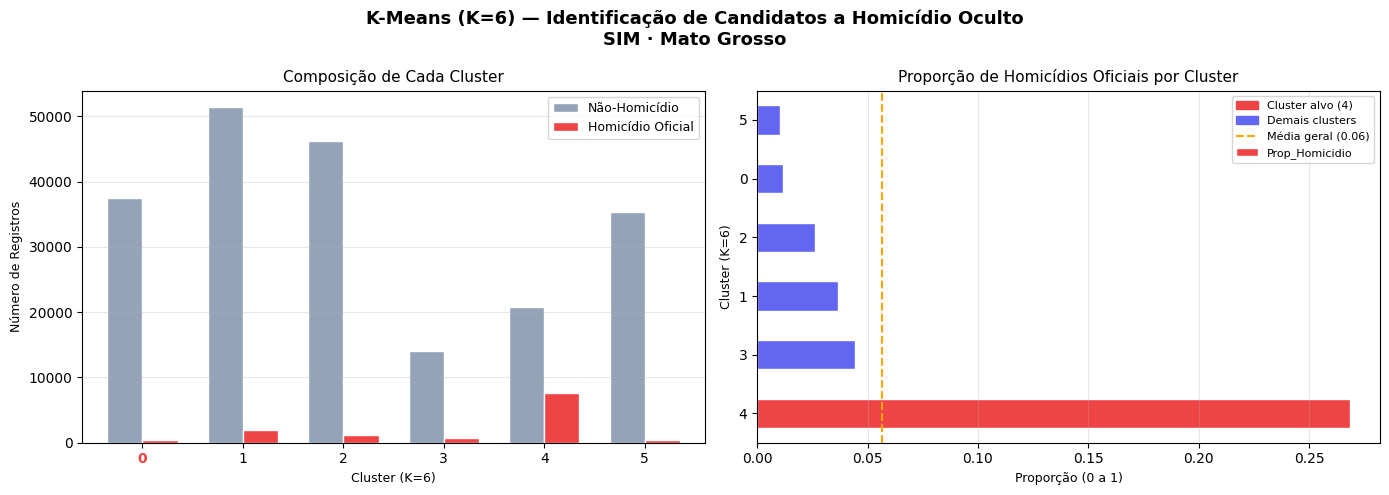

Gráfico salvo: kmeans_suspeitos.png

═════════════════════════════════════════════════════════════════
  TABELA FINAL — COMPARAÇÃO K-MEANS (melhor K)
═════════════════════════════════════════════════════════════════
       Modelo  Silhouette  Davies-Bouldin    ARI    NMI    FMI
K-Means (K=6)       0.166          1.9396 0.0131 0.0449 0.4203
═════════════════════════════════════════════════════════════════


In [35]:

# ══════════════════════════════════════════════════════════════════════════════
#  K-MEANS — Detecção de Homicídios Ocultos | SIM · Mato Grosso
#  K de 2 a 6 clusters com métricas internas e externas completas
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────
#  IMPORTS
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Métricas Internas
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Métricas Externas (requerem ground truth = HOMICIDIO)
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score,
)

# ─────────────────────────────────────────────────────────────────────────────
#  ETAPA 1 — PRÉ-PROCESSAMENTO
#  (adapta-se ao df_filtrado já carregado pelo pipeline principal)
# ─────────────────────────────────────────────────────────────────────────────

# Códigos CID-10 classificados como homicídio (ground truth)
cid10_homicidio = [
    "X85","X86","X87","X88","X89","X90","X91","X92","X93","X94","X95","X96","X97","X98","X99",
    "Y10","Y11","Y12","Y13","Y14","Y15","Y16","Y17","Y18","Y19","Y20","Y21","Y22","Y23","Y24",
    "Y25","Y26","Y27","Y28","Y29","Y30","Y31","Y32","Y33","Y34",
]

df_km = df_filtrado.copy()

df_km["HOMICIDIO"] = df_km["CAUSABAS_O"].astype(str).str[:3].isin(cid10_homicidio).astype(int)

# ── FIX 1: decodificar_idade agora converte float→int antes de processar ──────
def decodificar_idade(valor):
    try:
        if pd.isna(valor) or str(valor).strip() in ("", "nan", "None"):
            return np.nan
        s = str(int(float(valor)))  # '463' → '463' (sem zfill)
        if len(s) < 2:
            return np.nan
        tipo  = int(s[0])    # '4' → anos
        quant = int(s[1:])   # '63' → 63 anos
        if tipo == 4:   return quant
        elif tipo == 3: return quant / 12
        elif tipo == 2: return quant / 365
        elif tipo == 1: return quant / 8760
        else:           return np.nan
    except:
        return np.nan

df_km["IDADE_NUM"] = df_km["IDADE"].apply(decodificar_idade)

df_km["HORA_NUM"] = pd.to_numeric(
    df_km["HORAOBITO"].astype(str).str[:2], errors="coerce"
)

# ── FIX 2: mapas incluem TANTO os códigos numéricos QUANTO os textos já
#    substituídos pelo pipeline anterior (df_novo → df_filtrado) ───────────────

mapa_sexo = {
    "1": 1, "2": 2, "0": 0, "": 0,
    "M": 1, "F": 2, "I": 0,                     # variantes do SIM
    "masculino": 1, "feminino": 2, "ignorado": 0,
}
mapa_raca = {
    "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "": 0,
    "branca": 1, "preta": 2, "amarela": 3, "parda": 4, "indigena": 5,
}
mapa_estciv = {
    "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "9": 0, "": 0,
    "solteiro": 1, "casado": 2, "viuvo": 3, "separado": 4,
    "união estável": 5, "ignorado": 0,
}
mapa_esc = {
    "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "9": 0, "0": 0, "": 0,
    "nenhuma": 1, "1 a 3 anos": 2, "4 a 7 anos": 3,
    "8 a 11 anos": 4, "12 anos e mais": 5, "ignorado": 0,
}
mapa_lococor = {
    "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "9": 0, "": 0,
    "hospital": 1, "outros estabelecimentos de saude": 2,
    "domicílio": 3, "via pública": 4, "outros": 5, "ignorado": 0,
}

df_km["SEXO_NUM"]    = df_km["SEXO"].astype(str).str.strip().map(mapa_sexo)
df_km["RACACOR_NUM"] = df_km["RACACOR"].astype(str).str.strip().map(mapa_raca)
df_km["ESTCIV_NUM"]  = df_km["ESTCIV"].astype(str).str.strip().map(mapa_estciv)
df_km["ESC_NUM"]     = df_km["ESC"].astype(str).str.strip().map(mapa_esc)
df_km["LOCOCOR_NUM"] = df_km["LOCOCOR"].astype(str).str.strip().map(mapa_lococor)
df_km["ANO_NUM"]     = pd.to_numeric(df_km["ANO"], errors="coerce")

# GRAVIDEZ removida das features: NaN legítimo em todos os óbitos masculinos,
# distorce o espaço sem agregar informação sobre o perfil de homicídio.

# ── FIX 3: features sem GRAVIDEZ ──────────────────────────────────────────────
features = [
    "IDADE_NUM", "HORA_NUM", "SEXO_NUM", "RACACOR_NUM",
    "ESTCIV_NUM", "ESC_NUM", "LOCOCOR_NUM", "ANO_NUM"
]

# Diagnóstico — deve mostrar valores muito menores agora
print("\nNaNs após correção dos mapas:")
print(df_km[features].isnull().sum())
print(f"Total de registros: {len(df_km)}")

# ── Diagnóstico expandido para entender o IDADE ────────────────────────────
print("\nAmostra bruta de IDADE (antes da decodificação):")
print(df_km["IDADE"].dropna().head(20).tolist())
print(f"Tipo da coluna: {df_km['IDADE'].dtype}")
print(f"NaN em IDADE: {df_km['IDADE'].isna().sum()} / {len(df_km)}")

# ── FIX 4: imputação robusta — ignora features 100% NaN ───────────────────
df_modelo = df_km[features + ["HOMICIDIO"]].copy()

continuas   = ["IDADE_NUM", "HORA_NUM", "ANO_NUM"]
categoricas = ["SEXO_NUM", "RACACOR_NUM", "ESTCIV_NUM", "ESC_NUM", "LOCOCOR_NUM"]

# Filtrar apenas as que têm pelo menos um valor não-NaN
continuas_ok   = [f for f in continuas   if df_modelo[f].notna().any()]
categoricas_ok = [f for f in categoricas if df_modelo[f].notna().any()]

# Features completamente vazias: informar e remover
removidas = [f for f in features if f not in continuas_ok + categoricas_ok]
if removidas:
    print(f"\nFeatures removidas (100% NaN, sem dados para imputar): {removidas}")

if continuas_ok:
    imp_cont = SimpleImputer(strategy="median")
    df_modelo[continuas_ok] = imp_cont.fit_transform(df_modelo[continuas_ok])

if categoricas_ok:
    imp_cat = SimpleImputer(strategy="most_frequent")
    df_modelo[categoricas_ok] = imp_cat.fit_transform(df_modelo[categoricas_ok])

# Atualizar lista de features para usar apenas as válidas
features = continuas_ok + categoricas_ok

print(f"\nNaNs restantes após imputação: {df_modelo[features].isnull().sum().sum()}")
print(f"Features utilizadas: {features}")
print(f"Shape final: {df_modelo.shape}")

X      = df_modelo[features].values
y_true = df_modelo["HOMICIDIO"].values

print(f"\nRegistros para clusterização: {len(X)}")
print(f"Homicídios oficiais (CID-10): {y_true.sum()} ({y_true.mean()*100:.1f}%)")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ─────────────────────────────────────────────────────────────────────────────
#  ETAPA 2 — K-MEANS DE K=2 A K=6
#  Calculando todas as métricas para cada valor de K
# ─────────────────────────────────────────────────────────────────────────────

K_RANGE   = range(2, 7)
N_INIT    = 20
MAX_ITER  = 500
SEED      = 42

resultados    = []
modelos_km    = {}

print("\n" + "═"*65)
print("  K-MEANS — TREINAMENTO E MÉTRICAS")
print("═"*65)

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=N_INIT, max_iter=MAX_ITER, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    modelos_km[k] = {"modelo": km, "labels": labels}

    inertia  = km.inertia_
    sil = silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42)
    dbi      = davies_bouldin_score(X_scaled, labels)
    chi      = calinski_harabasz_score(X_scaled, labels)

    ari  = adjusted_rand_score(y_true, labels)
    nmi  = normalized_mutual_info_score(y_true, labels)
    fmi  = fowlkes_mallows_score(y_true, labels)

    prop_homic = (
        pd.Series(labels).rename("CLUSTER")
        .to_frame()
        .assign(HOMICIDIO=y_true)
        .groupby("CLUSTER")["HOMICIDIO"].mean()
    )
    cluster_alvo = prop_homic.idxmax()

    resultados.append({
        "K":            k,
        "WCSS":         round(inertia, 1),
        "Silhouette":   round(sil, 4),
        "Davies-Bouldin": round(dbi, 4),
        "Calinski-Harabasz": round(chi, 1),
        "ARI":          round(ari, 4),
        "NMI":          round(nmi, 4),
        "FMI":          round(fmi, 4),
        "Cluster_Alvo": cluster_alvo,
        "Prop_Homic_Alvo": round(prop_homic[cluster_alvo], 4),
    })

    print(f"\n  K = {k}")
    print(f"    WCSS (Inércia):        {inertia:,.1f}  ← menor melhor")
    print(f"    Silhouette:            {sil:.4f}       ← maior melhor (−1 a 1)")
    print(f"    Davies-Bouldin:        {dbi:.4f}       ← menor melhor (≥0)")
    print(f"    Calinski-Harabasz:     {chi:,.1f}   ← maior melhor")
    print(f"    ARI:                   {ari:.4f}       ← maior melhor (−1 a 1)")
    print(f"    NMI:                   {nmi:.4f}       ← maior melhor (0 a 1)")
    print(f"    FMI:                   {fmi:.4f}       ← maior melhor (0 a 1)")
    print(f"    Cluster c/ + homicídios: {cluster_alvo} ({prop_homic[cluster_alvo]*100:.1f}%)")

df_metricas_km = pd.DataFrame(resultados)
print("\n" + "═"*65)
print("  TABELA RESUMO — TODAS AS MÉTRICAS")
print("═"*65)
print(df_metricas_km.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
#  ETAPA 3 — GRÁFICOS DE MÉTRICAS
# ─────────────────────────────────────────────────────────────────────────────

COR_BASE = "#6366f1"
KS       = list(K_RANGE)

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "K-Means — Avaliação de K=2 a K=6 | SIM · Mato Grosso\nMétricas Internas e Externas",
    fontsize=15, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

def plot_metrica(ax, valores, titulo, ylabel, melhor="alto", cor=COR_BASE):
    ax.plot(KS, valores, "o-", color=cor, linewidth=2.2, markersize=8)
    for k, v in zip(KS, valores):
        ax.annotate(f"{v:.3f}", (k, v), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=8.5, fontweight="bold")
    melhor_k = KS[np.argmax(valores)] if melhor == "alto" else KS[np.argmin(valores)]
    ax.axvline(melhor_k, color="orange", linestyle="--", linewidth=1.5,
               label=f"Melhor K={melhor_k}")
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.set_xlabel("Número de Clusters (K)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(KS)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

ax1 = fig.add_subplot(gs[0, 0])
wcss_vals = df_metricas_km["WCSS"].tolist()
ax1.plot(KS, wcss_vals, "o-", color=COR_BASE, linewidth=2.2, markersize=8)
for k, v in zip(KS, wcss_vals):
    ax1.annotate(f"{v:,.0f}", (k, v), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=8, fontweight="bold")
deltas = np.diff(wcss_vals)
deltas2 = np.diff(deltas)
cotovelo_k = KS[1:-1][np.argmax(np.abs(deltas2))] if len(deltas2) > 0 else KS[0]
ax1.axvline(cotovelo_k, color="orange", linestyle="--", linewidth=1.5,
            label=f"Cotovelo K={cotovelo_k}")
ax1.set_title("Método do Cotovelo\n(WCSS / Inércia)", fontsize=10, fontweight="bold")
ax1.set_xlabel("K", fontsize=9); ax1.set_ylabel("WCSS (Inércia)", fontsize=9)
ax1.set_xticks(KS); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_metrica(ax2, df_metricas_km["Silhouette"].tolist(),
             "Coeficiente de Silhouette\n(Coesão + Separação)",
             "Silhouette Score", melhor="alto")

ax3 = fig.add_subplot(gs[0, 2])
plot_metrica(ax3, df_metricas_km["Davies-Bouldin"].tolist(),
             "Índice Davies-Bouldin\n(Dispersão vs Separação)",
             "DBI Score", melhor="baixo", cor="#ef4444")

ax4 = fig.add_subplot(gs[1, 0])
plot_metrica(ax4, df_metricas_km["Calinski-Harabasz"].tolist(),
             "Índice Calinski-Harabasz\n(Densidade vs Separação)",
             "CH Score", melhor="alto", cor="#10b981")

ax5 = fig.add_subplot(gs[1, 1])
plot_metrica(ax5, df_metricas_km["ARI"].tolist(),
             "Adjusted Rand Index (ARI)\n(Ground Truth: Homicídio CID-10)",
             "ARI Score", melhor="alto", cor="#f59e0b")

ax6 = fig.add_subplot(gs[1, 2])
plot_metrica(ax6, df_metricas_km["NMI"].tolist(),
             "Informação Mútua Normalizada (NMI)\n(Ground Truth: Homicídio CID-10)",
             "NMI Score", melhor="alto", cor="#8b5cf6")

ax7 = fig.add_subplot(gs[2, 0])
plot_metrica(ax7, df_metricas_km["FMI"].tolist(),
             "Fowlkes-Mallows Index (FMI)\n(Precisão × Recall dos Pares)",
             "FMI Score", melhor="alto", cor="#ec4899")

ax8 = fig.add_subplot(gs[2, 1:])
metricas_norm = df_metricas_km.set_index("K")[
    ["Silhouette","Davies-Bouldin","Calinski-Harabasz","ARI","NMI","FMI"]
].copy()

for col in metricas_norm.columns:
    mn, mx = metricas_norm[col].min(), metricas_norm[col].max()
    if mx == mn:
        metricas_norm[col] = 0.5
    else:
        if col == "Davies-Bouldin":
            metricas_norm[col] = 1 - (metricas_norm[col] - mn) / (mx - mn)
        else:
            metricas_norm[col] = (metricas_norm[col] - mn) / (mx - mn)

sns.heatmap(
    metricas_norm,
    annot=True, fmt=".2f", cmap="RdYlGn",
    linewidths=0.5, ax=ax8,
    cbar_kws={"label": "Score Normalizado (0-1, sempre maior = melhor)"},
    vmin=0, vmax=1
)
ax8.set_title(
    "Heatmap de Métricas Normalizadas\n(Verde = melhor; DBI já invertido)",
    fontsize=10, fontweight="bold"
)
ax8.set_xlabel("Métrica", fontsize=9)
ax8.set_ylabel("K", fontsize=9)

plt.savefig("kmeans_metricas_completas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: kmeans_metricas_completas.png")

# ─────────────────────────────────────────────────────────────────────────────
#  ETAPA 4 — SCATTER PCA 2D
# ─────────────────────────────────────────────────────────────────────────────

pca2d = PCA(n_components=2, random_state=SEED)
X_2d  = pca2d.fit_transform(X_scaled)
var_exp = pca2d.explained_variance_ratio_
xlabel  = f"PC1 ({var_exp[0]:.1%} variância)"
ylabel  = f"PC2 ({var_exp[1]:.1%} variância)"

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "K-Means — Distribuição dos Clusters no Espaço PCA 2D\nSIM · Mato Grosso",
    fontsize=14, fontweight="bold"
)
axes = axes.flatten()
palette = plt.cm.tab10.colors

ax = axes[0]
ax.set_title("Ground Truth\n(Homicídio CID-10 vs Demais)", fontsize=10)
for val, cor, lbl in [(0, "#94a3b8", "Não-homicídio"), (1, "#ef4444", "Homicídio oficial")]:
    mask = y_true == val
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=cor, s=7, alpha=0.5, label=lbl, rasterized=True)
ax.set_xlabel(xlabel, fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
ax.legend(markerscale=3, fontsize=8); ax.grid(alpha=0.2)

for idx, k in enumerate(K_RANGE, start=1):
    ax   = axes[idx]
    labs = modelos_km[k]["labels"]
    sil  = df_metricas_km.loc[df_metricas_km["K"]==k, "Silhouette"].values[0]
    dbi  = df_metricas_km.loc[df_metricas_km["K"]==k, "Davies-Bouldin"].values[0]
    ari  = df_metricas_km.loc[df_metricas_km["K"]==k, "ARI"].values[0]

    for c in range(k):
        mask = labs == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palette[c % len(palette)]], s=7, alpha=0.4,
                   label=f"C{c}", rasterized=True)

    centroides_2d = pca2d.transform(modelos_km[k]["modelo"].cluster_centers_)
    ax.scatter(centroides_2d[:, 0], centroides_2d[:, 1],
               c="black", s=80, marker="X", zorder=5, label="Centróide")

    ax.set_title(f"K = {k}", fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(markerscale=2, fontsize=7, ncol=2)
    ax.grid(alpha=0.2)

    txt = f"Silhouette: {sil:.3f}\nDBI: {dbi:.3f}\nARI: {ari:.3f}"
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top",
            fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))

plt.tight_layout()
plt.savefig("kmeans_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: kmeans_pca_clusters.png")

# ─────────────────────────────────────────────────────────────────────────────
#  ETAPA 5 — IDENTIFICAÇÃO DE CANDIDATOS A HOMICÍDIO OCULTO
# ─────────────────────────────────────────────────────────────────────────────

idx_melhor_k = df_metricas_km["Prop_Homic_Alvo"].idxmax()
melhor_k_pureza = int(df_metricas_km.loc[idx_melhor_k, "K"])

melhor_k_sil     = int(df_metricas_km.loc[df_metricas_km["Silhouette"].idxmax(), "K"])
melhor_k_ari     = int(df_metricas_km.loc[df_metricas_km["ARI"].idxmax(), "K"])

print(f"\n{'═'*65}")
print(f"  MELHOR K — Silhouette:            K = {melhor_k_sil}")
print(f"  MELHOR K — ARI (concordância):     K = {melhor_k_ari}")
print(f"  MELHOR K — Pureza do cluster alvo: K = {melhor_k_pureza}")
print(f"  → K escolhido: {melhor_k_pureza} (maior enriquecimento de homicídios)")
print(f"{'═'*65}")

K_FINAL = melhor_k_pureza   # foco em obter o grupo mais puro para a próxima etapa
labels_final = modelos_km[K_FINAL]["labels"]

df_modelo = df_modelo.copy()
df_modelo[f"CLUSTER_KMEANS_K{K_FINAL}"] = labels_final

prop_por_cluster = (
    df_modelo.groupby(f"CLUSTER_KMEANS_K{K_FINAL}")["HOMICIDIO"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "N_Homicidios", "mean": "Prop_Homicidio", "count": "N_Total"})
    .sort_values("Prop_Homicidio", ascending=False)
)
print(f"\nProporção de homicídios por cluster (K={K_FINAL}):")
print(prop_por_cluster.to_string())

cluster_alvo_final = prop_por_cluster.index[0]

suspeitos_km = df_modelo[
    (df_modelo["HOMICIDIO"] == 0) &
    (df_modelo[f"CLUSTER_KMEANS_K{K_FINAL}"] == cluster_alvo_final)
]

print(f"\n{'─'*65}")
print(f"  CANDIDATOS A HOMICÍDIO OCULTO (K-Means, K={K_FINAL}):")
print(f"  Cluster alvo:              {cluster_alvo_final}")
print(f"  Registros suspeitos:       {len(suspeitos_km)}")
print(f"  Total não-homicídios:      {(df_modelo['HOMICIDIO']==0).sum()}")
print(f"  % suspeitos no total:      {len(suspeitos_km)/(df_modelo['HOMICIDIO']==0).sum()*100:.1f}%")
print(f"{'─'*65}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"K-Means (K={K_FINAL}) — Identificação de Candidatos a Homicídio Oculto\nSIM · Mato Grosso",
    fontsize=13, fontweight="bold"
)

ax = axes[0]
df_plot = (
    df_modelo.groupby([f"CLUSTER_KMEANS_K{K_FINAL}", "HOMICIDIO"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Não-Homicídio", 1: "Homicídio Oficial"})
)
df_plot.plot(kind="bar", ax=ax, color=["#94a3b8", "#ef4444"],
             edgecolor="white", width=0.7)
ax.set_title("Composição de Cada Cluster", fontsize=11)
ax.set_xlabel(f"Cluster (K={K_FINAL})", fontsize=9)
ax.set_ylabel("Número de Registros", fontsize=9)
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.get_xticklabels()[list(prop_por_cluster.index).index(cluster_alvo_final)].set_color("#ef4444")
ax.get_xticklabels()[list(prop_por_cluster.index).index(cluster_alvo_final)].set_fontweight("bold")

ax2 = axes[1]
cores_bar = ["#ef4444" if i == cluster_alvo_final else "#6366f1"
             for i in prop_por_cluster.index]
prop_por_cluster["Prop_Homicidio"].plot(
    kind="barh", ax=ax2, color=cores_bar, edgecolor="white"
)
ax2.set_title("Proporção de Homicídios Oficiais por Cluster", fontsize=11)
ax2.set_xlabel("Proporção (0 a 1)", fontsize=9)
ax2.set_ylabel(f"Cluster (K={K_FINAL})", fontsize=9)
ax2.axvline(y_true.mean(), color="orange", linestyle="--", linewidth=1.5,
            label=f"Média geral ({y_true.mean():.2f})")
ax2.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legenda_extra = [
    Patch(color="#ef4444", label=f"Cluster alvo ({cluster_alvo_final})"),
    Patch(color="#6366f1", label="Demais clusters"),
]
ax2.legend(handles=legenda_extra + ax2.get_legend_handles_labels()[0], fontsize=8)

plt.tight_layout()
plt.savefig("kmeans_suspeitos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: kmeans_suspeitos.png")

# ─────────────────────────────────────────────────────────────────────────────
#  ETAPA 6 — COMPARAÇÃO FINAL
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*65)
print("  TABELA FINAL — COMPARAÇÃO K-MEANS (melhor K)")
print("═"*65)

linha_km = df_metricas_km[df_metricas_km["K"] == K_FINAL].iloc[0]
resultado_db  = {}
resultado_hdb = {}

tabela_final = {
    "Modelo":         [f"K-Means (K={K_FINAL})"],
    "Silhouette":     [linha_km["Silhouette"]],
    "Davies-Bouldin": [linha_km["Davies-Bouldin"]],
    "ARI":            [linha_km["ARI"]],
    "NMI":            [linha_km["NMI"]],
    "FMI":            [linha_km["FMI"]],
}

df_final_comp = pd.DataFrame(tabela_final)
print(df_final_comp.to_string(index=False))
print("═"*65)